In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, ccf
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.metrics import mean_squared_error

# Load data
df = pd.read_csv('data_files/box_data_60min.csv')
df['tdate'] = pd.to_datetime(df['tdate'])
df.head()

,thour,tdate,Ph,Tdelta,Gv,Ph.l0,Ph.l1,Ph.l2,Ph.l3,Ph.l4,...,Gv.l1,Gv.l2,Gv.l3,Gv.l4,Gv.l5,Gv.l6,Gv.l7,Gv.l8,Gv.l9,Gv.l10
0,19,2013-01-30 02:00:00,56,13.253583,-0.498643,56,55,57,57,58,...,-0.499338,-0.417959,-0.221011,-0.453375,-0.747238,-0.669267,-0.451776,-0.142700,8.262339,20.475484
1,20,2013-01-30 03:00:00,54,13.181458,-1.127035,54,56,55,57,57,...,-0.498643,-0.499338,-0.417959,-0.221011,-0.453375,-0.747238,-0.669267,-0.451776,-0.142700,8.262339
2,21,2013-01-30 04:00:00,55,12.968792,-0.643298,55,54,56,55,57,...,-1.127035,-0.498643,-0.499338,-0.417959,-0.221011,-0.453375,-0.747238,-0.669267,-0.451776,-0.142700
3,22,2013-01-30 05:00:00,54,12.667750,-0.456008,54,55,54,56,55,...,-0.643298,-1.127035,-0.498643,-0.499338,-0.417959,-0.221011,-0.453375,-0.747238,-0.669267,-0.451776
4,23,2013-01-30 06:00:00,54,12.605250,-1.534060,54,54,55,54,56,...,-0.456008,-0.643298,-1.127035,-0.498643,-0.499338,-0.417959,-0.221011,-0.453375,-0.747238,-0.669267


In [2]:
# Plot the three main variables
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(df['tdate'], df['Ph'], color='red')
axes[0].set_title('Heating power Ph (W)')

axes[1].plot(df['tdate'], df['Tdelta'], color='blue')
axes[1].set_title('Temperature difference Tdelta (?C)')

axes[2].plot(df['tdate'], df['Gv'], color='orange')
axes[2].set_title('Global solar irradiance Gv (W/m?)')

plt.tight_layout()
plt.show()

# Description:
# Ph shows periodic behavior (high at night, low during the day).
# Gv shows clear peaks during the day. 
# A strong negative correlation is visible: when Gv increases, Ph decreases immediately.

In [3]:
# Split at thour = 167
train_df = df[df['thour'] <= 186].copy()
test_df = df[df['thour'] > 186].copy()

print(f"Training data: {len(train_df)} hours")
print(f"Test data: {len(test_df)} hours")

Training data: 168 hours
Test data: 63 hours


In [4]:
# Expand the layout to 1 row and 3 columns
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# 1. ACF of Ph
plot_acf(train_df['Ph'], lags=40, ax=ax[0])
ax[0].set_title('ACF of Ph')

# Prepare data for the CCFs
lags = range(11)
ccf_tdelta = [np.corrcoef(train_df['Ph'], train_df[f'Tdelta.l{i}'])[0,1] for i in lags]
ccf_gv = [np.corrcoef(train_df['Ph'], train_df[f'Gv.l{i}'])[0,1] for i in lags]

# 2. CCF: Ph vs Tdelta
ax[1].bar(lags, ccf_tdelta, color='firebrick', alpha=0.7)
ax[1].set_title('CCF: Ph vs Tdelta (Heating demand)')
ax[1].set_xlabel('Lag')
ax[1].set_ylabel('Correlation')
ax[1].grid(True, linestyle='--', alpha=0.6)

# 3. CCF: Ph vs Gv
ax[2].bar(lags, ccf_gv, color='orange', alpha=0.7)
ax[2].set_title('CCF: Ph vs Gv (Solar gain)')
ax[2].set_xlabel('Lag')
ax[2].set_ylabel('Correlation')
ax[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Train size: 168, Test size: 63
Ph Range: 17 to 96
Tdelta Range: 12.573 to 24.49675
Gv Range: -1.60216408268333 to 515.796253229983


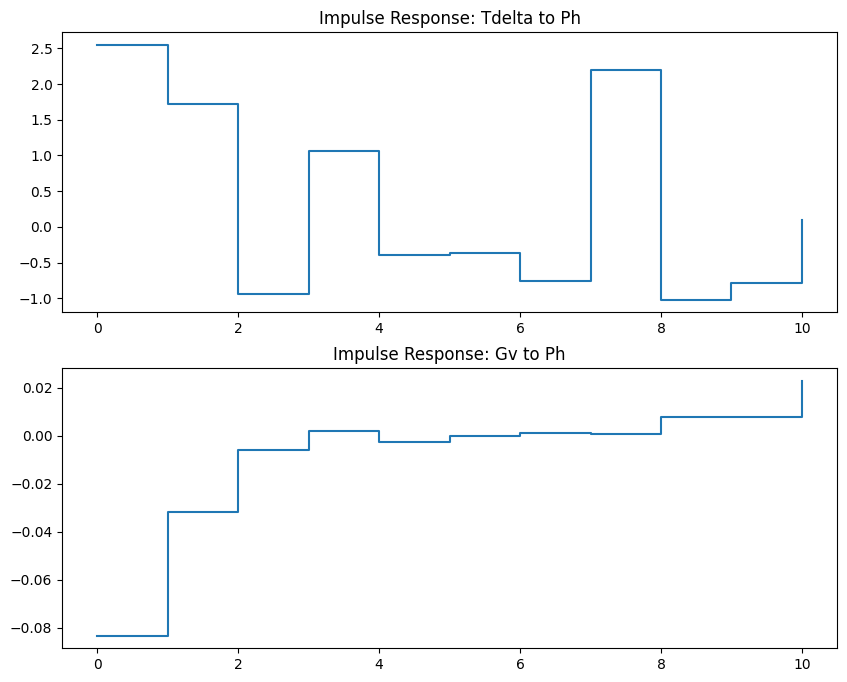

In [5]:
from sklearn.linear_model import LinearRegression
# 3.4 Impulse Response up to lag 10
# Regression Ph ~ Tdelta.l0 ... Tdelta.l10
X_tdelta = train_df[[f'Tdelta.l{i}' for i in range(11)]]
y = train_df['Ph']
model_tdelta = LinearRegression().fit(X_tdelta, y)
ir_tdelta = model_tdelta.coef_

# Regression Ph ~ Gv.l0 ... Gv.l10
X_gv = train_df[[f'Gv.l{i}' for i in range(11)]]
model_gv = LinearRegression().fit(X_gv, y)
ir_gv = model_gv.coef_

fig, axes = plt.subplots(2, 1, figsize=(10, 8))
axes[0].step(range(11), ir_tdelta, where='post')
axes[0].set_title('Impulse Response: Tdelta to Ph')
axes[1].step(range(11), ir_gv, where='post')
axes[1].set_title('Impulse Response: Gv to Ph')
plt.savefig('impulse_response.png')

# Output some summary statistics or info to help description
print(f"Train size: {len(train_df)}, Test size: {len(test_df)}")
print(f"Ph Range: {train_df['Ph'].min()} to {train_df['Ph'].max()}")
print(f"Tdelta Range: {train_df['Tdelta'].min()} to {train_df['Tdelta'].max()}")
print(f"Gv Range: {train_df['Gv'].min()} to {train_df['Gv'].max()}")

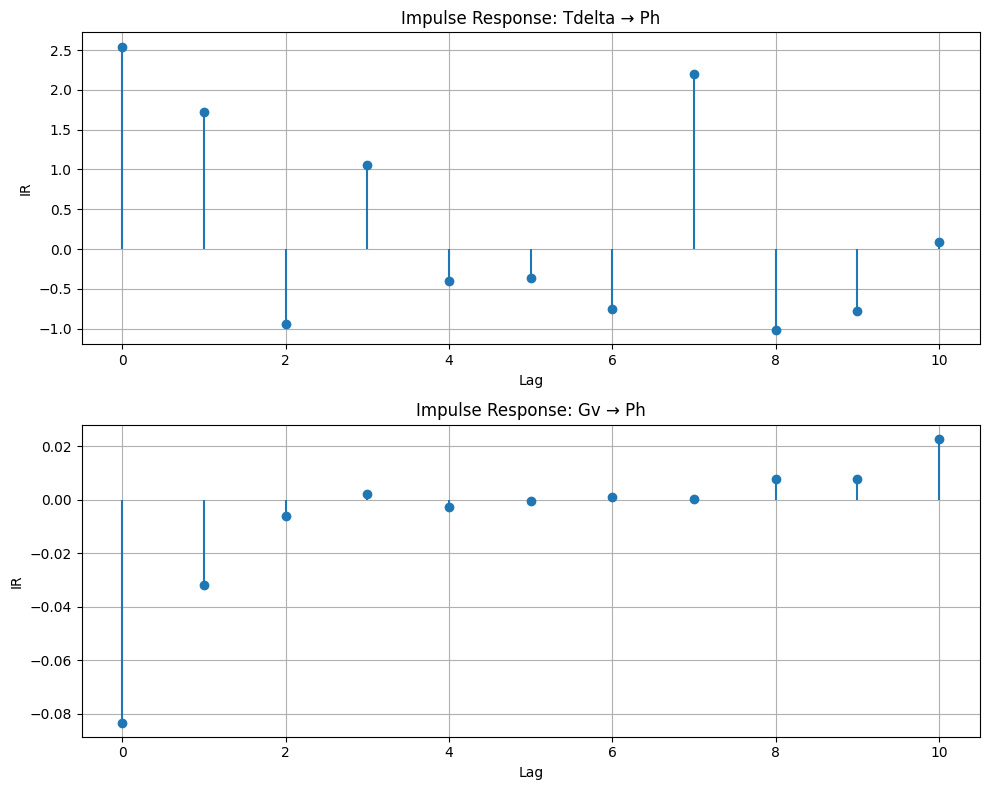

In [6]:
import matplotlib.pyplot as plt

lags = range(11)

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Tdelta → Ph
axes[0].stem(lags, ir_tdelta, basefmt=" ")
axes[0].set_title('Impulse Response: Tdelta → Ph')
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('IR')
axes[0].grid(True)

# Gv → Ph
axes[1].stem(lags, ir_gv, basefmt=" ")
axes[1].set_title('Impulse Response: Gv → Ph')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('IR')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import ccf

# -----------------------------
# 1. Model (without constant)
# -----------------------------
X_35 = train_df[['Tdelta', 'Gv']]
y_35 = train_df['Ph']
print(len(X_35))

model_35 = sm.OLS(y_35, X_35).fit()

print(model_35.summary())

# -----------------------------
# 2. One-step Prediction
# -----------------------------
train_df['Ph_pred_35'] = model_35.predict(X_35)

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import ccf

# 1. Calculations (residuals and CCF)
train_df['Ph_pred_35'] = model_35.predict(X_35)
train_df['resid_35'] = model_35.resid
lags = 40
ccf_Tdelta = ccf(train_df['resid_35'], train_df['Tdelta'])[:lags]
ccf_Gv = ccf(train_df['resid_35'], train_df['Gv'])[:lags]

# 2. Create the figure with subplots
# Create a grid: 3 rows, 2 columns
fig = plt.figure(figsize=(14, 15))
gs = fig.add_gridspec(3, 2)

# --- Row 1: One-step prediction (spans both columns) ---
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(train_df['Ph'].values, label='True Ph', color='steelblue')
ax1.plot(train_df['Ph_pred_35'].values, label='Predicted Ph', alpha=0.8, color='darkorange')
ax1.set_title('One-step Prediction vs True Values')
ax1.legend()
ax1.grid(True)

# --- Row 2: Residual analysis ---
# (a) Over time
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(train_df['resid_35'].values, color='firebrick')
ax2.set_title('Residuals over Time')
ax2.grid(True)

# (b) Histogram
ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(train_df['resid_35'], bins=30, color='gray', edgecolor='black')
ax3.set_title('Histogram of Residuals')
ax3.grid(True)

# --- Row 3: CCF (Residuals vs Inputs) ---
# CCF for Tdelta
ax4 = fig.add_subplot(gs[2, 0])
ax4.stem(range(lags), ccf_Tdelta)
ax4.set_title('CCF: Residuals vs Tdelta')
ax4.set_xlabel('Lag')
ax4.set_ylabel('Correlation')
ax4.grid(True)

# CCF for Gv
ax5 = fig.add_subplot(gs[2, 1])
ax5.stem(range(lags), ccf_Gv)
ax5.set_title('CCF: Residuals vs Gv')
ax5.set_xlabel('Lag')
ax5.set_ylabel('Correlation')
ax5.grid(True)

# Optimize the layout so the titles do not overlap
plt.tight_layout()
plt.show()

168
                                 OLS Regression Results                                
Dep. Variable:                     Ph   R-squared (uncentered):                   0.995
Model:                            OLS   Adj. R-squared (uncentered):              0.994
Method:                 Least Squares   F-statistic:                          1.512e+04
Date:                Fri, 10 Apr 2026   Prob (F-statistic):                   1.50e-188
Time:                        09:22:00   Log-Likelihood:                         -521.42
No. Observations:                 168   AIC:                                      1047.
Df Residuals:                     166   BIC:                                      1053.
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------

In [8]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import ccf

# 1. Calculations
train_df['Ph_pred_35'] = model_35.predict(X_35)
train_df['resid_35'] = model_35.resid
lags = 40
ccf_Tdelta = ccf(train_df['resid_35'], train_df['Tdelta'])[:lags]
ccf_Gv = ccf(train_df['resid_35'], train_df['Gv'])[:lags]

# 2. Figure setup with 3 rows
# Use a 6-column background grid to control the widths flexibly
fig = plt.figure(figsize=(15, 18))
gs = fig.add_gridspec(3, 6)

# --- Row 1: One-step prediction (full width) ---
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(train_df['Ph'].values, label='True Ph', color='steelblue')
ax1.plot(train_df['Ph_pred_35'].values, label='Predicted Ph', alpha=0.8, color='darkorange', linestyle='--')
ax1.set_title('One-step Prediction vs True Values', fontsize=14)
ax1.legend()
ax1.grid(True)

# --- Row 2: Residual analysis (three plots side by side) ---
# Over time
ax2 = fig.add_subplot(gs[1, 0:3]) # Columns 0 and 1
ax2.plot(train_df['resid_35'].values, color='firebrick', lw=0.5)
ax2.set_title('Residuals over Time')
ax2.grid(True)



# ACF of residuals
ax4 = fig.add_subplot(gs[1, 3:6]) # Columns 4 and 5
plot_acf(train_df['resid_35'], lags=lags, ax=ax4)
ax4.set_title('ACF of Residuals')
ax4.grid(True)

# --- Row 3: CCF (two plots side by side) ---
# CCF for Tdelta
ax5 = fig.add_subplot(gs[2, 0:3]) # Left half
ax5.stem(range(lags), ccf_Tdelta)
ax5.set_title('CCF: Residuals vs Tdelta')
ax5.set_xlabel('Lag')
ax5.set_ylabel('Correlation')
ax5.grid(True)

# CCF for Gv
ax6 = fig.add_subplot(gs[2, 3:6]) # Right half
ax6.stem(range(lags), ccf_Gv)
ax6.set_title('CCF: Residuals vs Gv')
ax6.set_xlabel('Lag')
ax6.set_ylabel('Correlation')
ax6.grid(True)

plt.tight_layout()
plt.show()

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import ccf

# -----------------------------
# 1. Prepare the data
# -----------------------------
# Make sure no NaNs (from lagging) interfere with the model
train_arx = train_df

# Define the regressors (lagged Ph, Tdelta, Gv)
X_arx = train_arx[['Ph.l1', 'Tdelta', 'Gv']]
y_arx = train_arx['Ph']

# -----------------------------
# 2. Fit the ARX(1) model
# -----------------------------
# Fit without a constant according to the assignment
model_arx = sm.OLS(y_arx, X_arx).fit()

print("--- ARX(1) Model Summary ---")
print(model_arx.summary())

# Extract the coefficient phi_1 (because Ph,t = -phi_1 * Ph,t-1)
phi_1_est = -model_arx.params['Ph.l1']
print(f"\nEstimated phi_1: {phi_1_est:.4f}")

# -----------------------------
# 3. Predictions and residuals
# -----------------------------
train_arx['Ph_pred_arx'] = model_arx.predict(X_arx)
train_arx['resid_arx'] = model_arx.resid

# CCF calculations
lags = 40
ccf_T_arx = ccf(train_arx['resid_arx'], train_arx['Tdelta'])[:lags]
ccf_G_arx = ccf(train_arx['resid_arx'], train_arx['Gv'])[:lags]

# -----------------------------
# 4. Visualization
# -----------------------------
# -----------------------------
# 4. Visualization (without histogram)
# -----------------------------
fig = plt.figure(figsize=(14, 15))
gs = fig.add_gridspec(3, 2)

# --- Row 1: One-step prediction (full width) ---
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(train_arx['Ph'].values, label='True Ph', color='steelblue', lw=1.5)
ax1.plot(train_arx['Ph_pred_arx'].values, label='ARX(1) Prediction', color='crimson', alpha=0.7, linestyle='--')
ax1.set_title('ARX(1) One-step Prediction vs True Values')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Row 2: Residuals and ACF ---
# (a) Residuals over time
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(train_arx['resid_arx'].values, color='firebrick', lw=1)
ax2.set_title('ARX Residuals over Time')
ax2.grid(True, alpha=0.3)

# (b) ACF of residuals
ax3 = fig.add_subplot(gs[1, 1])
plot_acf(train_arx['resid_arx'], ax=ax3, lags=lags, color='firebrick')
ax3.set_title('ACF of Residuals')
ax3.grid(True, alpha=0.3)

# --- Row 3: CCF (Residuals vs Inputs) ---
# CCF for Tdelta
ax4 = fig.add_subplot(gs[2, 0])
ax4.stem(range(lags), ccf_T_arx)
ax4.set_title('CCF: Residuals vs Tdelta')
ax4.set_xlabel('Lag')
ax4.set_ylabel('Correlation')
ax4.grid(True, alpha=0.3)

# CCF for Gv
ax5 = fig.add_subplot(gs[2, 1])
ax5.stem(range(lags), ccf_G_arx)
ax5.set_title('CCF: Residuals vs Gv')
ax5.set_xlabel('Lag')
ax5.set_ylabel('Correlation')
ax5.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# -----------------------------
# 5. Comment on the improvement
# -----------------------------
print("\n--- Improvement analysis ---")
print(f"Previous model (R-squared): {model_35.rsquared:.4f}")
print(f"ARX(1) model (R-squared): {model_arx.rsquared:.4f}")

--- ARX(1) Model Summary ---
                                 OLS Regression Results                                
Dep. Variable:                     Ph   R-squared (uncentered):                   0.999
Model:                            OLS   Adj. R-squared (uncentered):              0.999
Method:                 Least Squares   F-statistic:                          4.117e+04
Date:                Fri, 10 Apr 2026   Prob (F-statistic):                   7.01e-237
Time:                        09:22:04   Log-Likelihood:                         -403.09
No. Observations:                 168   AIC:                                      812.2
Df Residuals:                     165   BIC:                                      821.5
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
------------


--- Improvement analysis ---
Previous model (R-squared): 0.9945
ARX(1) model (R-squared): 0.9987


In [10]:
import pandas as pd
import statsmodels.api as sm

# Define orders 1 to 10
Order1 = train_df[['Ph.l1', 'Tdelta', 'Gv']]

Order2 = train_df[['Ph.l1','Ph.l2','Tdelta','Tdelta.l1','Gv','Gv.l1']]

Order3 = train_df[['Ph.l1','Ph.l2','Ph.l3','Tdelta','Tdelta.l1','Tdelta.l2','Gv','Gv.l1','Gv.l2']]

Order4 = train_df[['Ph.l1','Ph.l2','Ph.l3','Ph.l4',
                   'Tdelta','Tdelta.l1','Tdelta.l2','Tdelta.l3',
                   'Gv','Gv.l1','Gv.l2','Gv.l3']]

Order5 = train_df[['Ph.l1','Ph.l2','Ph.l3','Ph.l4','Ph.l5',
                   'Tdelta','Tdelta.l1','Tdelta.l2','Tdelta.l3','Tdelta.l4',
                   'Gv','Gv.l1','Gv.l2','Gv.l3','Gv.l4']]

Order6 = train_df[['Ph.l1','Ph.l2','Ph.l3','Ph.l4','Ph.l5','Ph.l6',
                   'Tdelta.l0','Tdelta.l1','Tdelta.l2','Tdelta.l3','Tdelta.l4','Tdelta.l5',
                   'Gv.l0','Gv.l1','Gv.l2','Gv.l3','Gv.l4','Gv.l5']]

Order7 = train_df[['Ph.l1','Ph.l2','Ph.l3','Ph.l4','Ph.l5','Ph.l6','Ph.l7',
                   'Tdelta','Tdelta.l1','Tdelta.l2','Tdelta.l3','Tdelta.l4','Tdelta.l5','Tdelta.l6',
                   'Gv','Gv.l1','Gv.l2','Gv.l3','Gv.l4','Gv.l5','Gv.l6']]

Order8 = train_df[['Ph.l1','Ph.l2','Ph.l3','Ph.l4','Ph.l5','Ph.l6','Ph.l7','Ph.l8',
                   'Tdelta','Tdelta.l1','Tdelta.l2','Tdelta.l3','Tdelta.l4','Tdelta.l5','Tdelta.l6','Tdelta.l7',
                   'Gv','Gv.l1','Gv.l2','Gv.l3','Gv.l4','Gv.l5','Gv.l6','Gv.l7']]

Order9 = train_df[['Ph.l1','Ph.l2','Ph.l3','Ph.l4','Ph.l5','Ph.l6','Ph.l7','Ph.l8','Ph.l9',
                   'Tdelta','Tdelta.l1','Tdelta.l2','Tdelta.l3','Tdelta.l4','Tdelta.l5','Tdelta.l6','Tdelta.l7','Tdelta.l8',
                   'Gv','Gv.l1','Gv.l2','Gv.l3','Gv.l4','Gv.l5','Gv.l6','Gv.l7','Gv.l8']]

Order10 = train_df[['Ph.l1','Ph.l2','Ph.l3','Ph.l4','Ph.l5','Ph.l6','Ph.l7','Ph.l8','Ph.l9','Ph.l10',
                    'Tdelta','Tdelta.l1','Tdelta.l2','Tdelta.l3','Tdelta.l4','Tdelta.l5','Tdelta.l6','Tdelta.l7','Tdelta.l8','Tdelta.l9',
                    'Gv','Gv.l1','Gv.l2','Gv.l3','Gv.l4','Gv.l5','Gv.l6','Gv.l7','Gv.l8','Gv.l9']]

# List of all orders
orders = [Order1, Order2, Order3, Order4, Order5, Order6, Order7, Order8, Order9, Order10]

# BIC and AIC comparison
results = []
for i, order_df in enumerate(orders, start=1):
    X = order_df
    y = train_df['Ph']  # Adjust 'Target' to your target variable
    model = sm.OLS(y, X).fit()
    results.append({'Order': i, 'AIC': model.aic, 'BIC': model.bic})

bic_aic_df = pd.DataFrame(results)
print(bic_aic_df)

   Order         AIC         BIC
0      1  812.173531  821.545423
1      2  761.619330  780.363114
2      3  742.820511  770.936187
3      4  723.121597  760.609165
4      5  710.457618  757.317078
5      6  704.251779  760.483130
6      7  708.332005  773.935248
7      8  711.517761  786.492897
8      9  713.904253  798.251281
9     10  709.059382  802.778301


In [11]:
import matplotlib.pyplot as plt

# Create plot
plt.figure(figsize=(10,6))
plt.plot(bic_aic_df['Order'], bic_aic_df['AIC'], marker='o', label='AIC')
plt.plot(bic_aic_df['Order'], bic_aic_df['BIC'], marker='s', label='BIC')

plt.xticks(range(1, 11))
plt.xlabel('Order')
plt.ylabel('Value')
plt.title('AIC and BIC comparison for orders 1 to 10')
plt.legend()
plt.grid(True)
plt.show()

63
63
63
63
63
63
63
63
63
63
   Order         AIC         BIC      RMSE
0      1  812.173531  821.545423  3.776819
1      2  761.619330  780.363114  3.269623
2      3  742.820511  770.936187  2.897892
3      4  723.121597  760.609165  3.062876
4      5  710.457618  757.317078  3.151848
5      6  704.251779  760.483130  3.359177
6      7  708.332005  773.935248  3.351342
7      8  711.517761  786.492897  3.296633
8      9  713.904253  798.251281  3.287714
9     10  709.059382  802.778301  3.324089


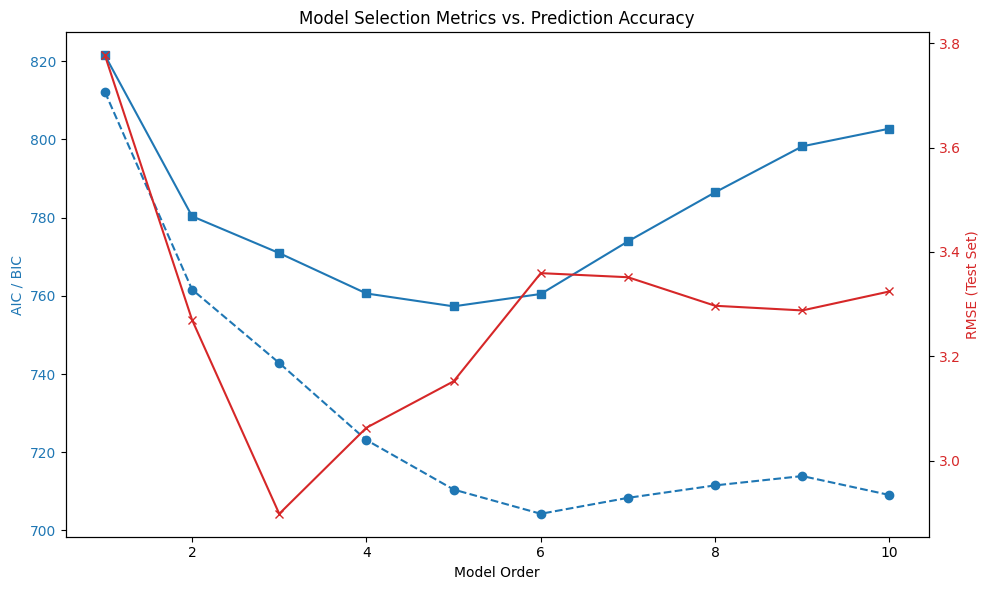

In [12]:
import numpy as np

# Assuming test_df contains the observations from t=168 to 231
# And 'Ph' is your target variable
y_test = test_df['Ph']
rmse_results = []

for i, order_df in enumerate(orders, start=1):
    # 1. Re-fit/Access the model for this order
    X_train = order_df
    y_train = train_df['Ph']
    model = sm.OLS(y_train, X_train).fit()
    
    # 2. Prepare Test Features (must match the column names of X_train)
    # Ensure test_df has the same lagged columns available
    X_test = test_df[X_train.columns]
    print(len(test_df))
    
    # 3. One-step ahead prediction: y_hat = X_test * beta
    y_pred = model.predict(X_test)
    
    # 4. Calculate RMSE
    errors = y_test - y_pred
    rmse = np.sqrt(np.mean(errors**2))
    
    rmse_results.append({'Order': i, 'RMSE': rmse})

# Combine with previous AIC/BIC results for comparison
comparison_df = bic_aic_df.merge(pd.DataFrame(rmse_results), on='Order')
print(comparison_df)

# Plotting
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('Model Order')
ax1.set_ylabel('AIC / BIC', color='tab:blue')
ax1.plot(comparison_df['Order'], comparison_df['AIC'], label='AIC', marker='o', color='tab:blue', linestyle='--')
ax1.plot(comparison_df['Order'], comparison_df['BIC'], label='BIC', marker='s', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('RMSE (Test Set)', color='tab:red')
ax2.plot(comparison_df['Order'], comparison_df['RMSE'], label='RMSE', marker='x', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Model Selection Metrics vs. Prediction Accuracy')
fig.tight_layout()
plt.show()